TASK 4: FORECASTING ACCESS AND USAGE (2025-2027)

1. LOADING DATA...
----------------------------------------

2. EXTRACTING HISTORICAL DATA...
----------------------------------------
Available indicators: ['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'ACC_4G_COV', 'ACC_MOBILE_PEN', 'ACC_FAYDA', 'USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE', 'USG_MPESA_USERS', 'USG_MPESA_ACTIVE', 'USG_ACTIVE_RATE', 'AFF_DATA_INCOME', 'GEN_GAP_ACC', 'GEN_MM_SHARE', 'GEN_GAP_MOBILE', 'ACC_OWNERSHIP_FEMALE', 'USG_MM_ACTIVE']

Access data: 18 points from ['ACC_OWNERSHIP', 'ACC_MM_ACCOUNT', 'ACC_4G_COV', 'ACC_MOBILE_PEN', 'ACC_FAYDA', 'GEN_GAP_ACC', 'ACC_OWNERSHIP_FEMALE']
Usage data: 13 points from ['USG_P2P_COUNT', 'USG_P2P_VALUE', 'USG_ATM_COUNT', 'USG_ATM_VALUE', 'USG_CROSSOVER', 'USG_TELEBIRR_USERS', 'USG_TELEBIRR_VALUE', 'USG_MPESA_USERS', 'USG_MPESA_ACTIVE', 'USG_ACTIVE_RATE', 'USG_MM_ACTIVE']
Mobile money data: 7 points from ['

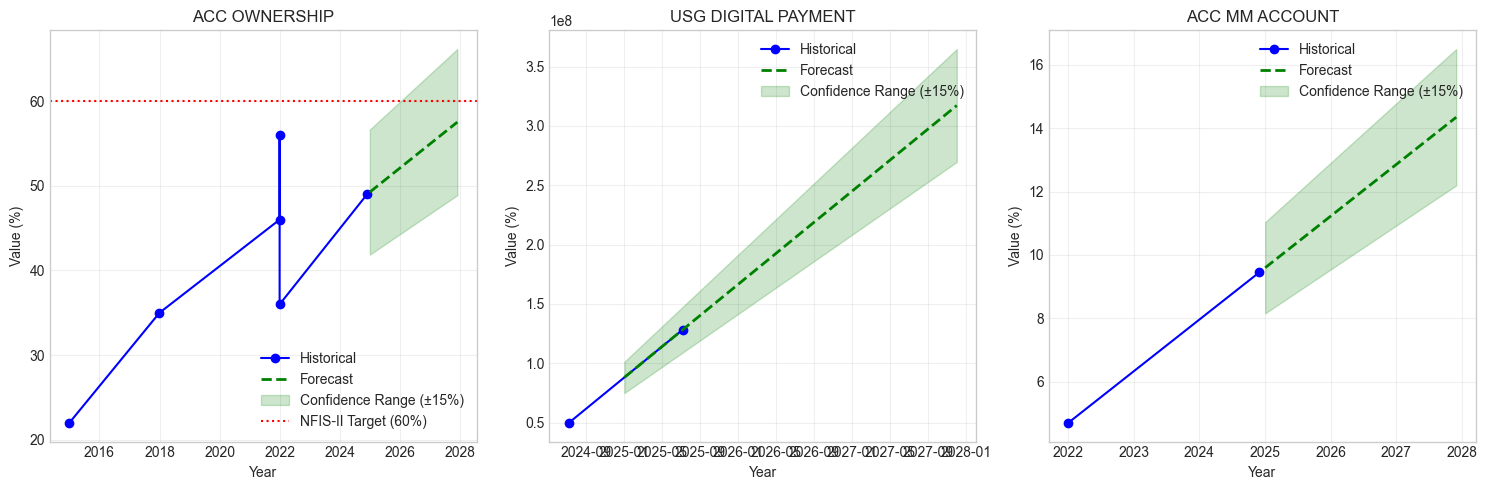


8. EVENT IMPACT ANALYSIS...
----------------------------------------

Future events that could impact forecasts:
  - NBE (2024)
  - EthSwitch (2024)
  - EthSwitch (2025)
  - NBE/EthSwitch (2025)
  - News (2025)

9. SCENARIO ANALYSIS...
----------------------------------------

Scenario assumptions:
  Pessimistic: Slower adoption, fewer events
  Base: Expected events materialize
  Optimistic: Accelerated adoption, stronger impacts

Scenario forecasts for 2027:

Pessimistic Scenario:
  ACC_OWNERSHIP: 55.8%
  USG_DIGITAL_PAYMENT: 307640682.2%
  ACC_MM_ACCOUNT: 13.9%

Base Scenario:
  ACC_OWNERSHIP: 57.5%
  USG_DIGITAL_PAYMENT: 317155342.5%
  ACC_MM_ACCOUNT: 14.3%

Optimistic Scenario:
  ACC_OWNERSHIP: 59.2%
  USG_DIGITAL_PAYMENT: 326670002.7%
  ACC_MM_ACCOUNT: 14.8%

10. SAVING FORECAST RESULTS...
----------------------------------------
Base forecast saved to: ../data/processed/forecast_base_2025_2027.csv
Pessimistic forecast saved to: ../data/processed/forecast_pessimistic_2025_2027.cs

In [2]:
# Task 4: Forecasting Access and Usage 2025-2027 - CORRECTED
# Forecasting Financial Inclusion in Ethiopia

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
from scipy import stats
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 60)
print("TASK 4: FORECASTING ACCESS AND USAGE (2025-2027)")
print("=" * 60)

# 1. Load Data
print("\n1. LOADING DATA...")
print("-" * 40)

df = pd.read_csv('../data/raw/ethiopia_fi_unified_data.csv')
df['observation_date'] = pd.to_datetime(df['observation_date'])

# 2. Extract Historical Data
print("\n2. EXTRACTING HISTORICAL DATA...")
print("-" * 40)

observations = df[df['record_type'] == 'observation']

# Get all available indicators
available_indicators = observations['indicator_code'].unique().tolist()
print(f"Available indicators: {available_indicators}")

# Check what indicators we have
access_data = None
usage_data = None
mm_data = None

# Try to find access indicator
access_indicators = [ind for ind in available_indicators if 'ACC' in ind or 'OWNERSHIP' in ind]
if access_indicators:
    access_data = observations[observations['indicator_code'].isin(access_indicators)].copy()
    access_data = access_data.sort_values('observation_date')
    print(f"\nAccess data: {len(access_data)} points from {access_indicators}")

# Try to find usage indicator
usage_indicators = [ind for ind in available_indicators if 'USG' in ind or 'PAYMENT' in ind or 'DIGITAL' in ind]
if usage_indicators:
    usage_data = observations[observations['indicator_code'].isin(usage_indicators)].copy()
    usage_data = usage_data.sort_values('observation_date')
    print(f"Usage data: {len(usage_data)} points from {usage_indicators}")

# Try to find mobile money indicator
mm_indicators = [ind for ind in available_indicators if 'MM' in ind or 'MOBILE' in ind]
if mm_indicators:
    mm_data = observations[observations['indicator_code'].isin(mm_indicators)].copy()
    mm_data = mm_data.sort_values('observation_date')
    print(f"Mobile money data: {len(mm_data)} points from {mm_indicators}")

# 3. Data Preparation Function
print("\n3. PREPARING DATA FOR MODELING...")
print("-" * 40)

def prepare_trend_data(data, indicator_name):
    """Prepare data for trend modeling."""
    if data is None or len(data) < 2:
        print(f"Not enough data for {indicator_name}: {len(data) if data is not None else 0} points")
        return None
    
    # Get the latest indicator if multiple exist
    if len(data['indicator_code'].unique()) > 1:
        # Use the one with most data points
        most_common = data['indicator_code'].value_counts().index[0]
        data = data[data['indicator_code'] == most_common]
        print(f"Using {most_common} for {indicator_name}")
    
    return data

# Prepare each dataset
access_prepared = prepare_trend_data(access_data, "Access")
usage_prepared = prepare_trend_data(usage_data, "Usage")
mm_prepared = prepare_trend_data(mm_data, "Mobile Money")

# 4. Trend Modeling Function
print("\n4. TREND MODELING...")
print("-" * 40)

def fit_trend_model(data, indicator_name):
    """Fit a linear trend model to historical data."""
    if data is None or len(data) < 2:
        print(f"Skipping {indicator_name}: insufficient data")
        return None
    
    # Prepare data
    X = np.array([(d - data['observation_date'].min()).days for d in data['observation_date']]).reshape(-1, 1)
    y = data['value_numeric'].values
    
    # Fit linear regression
    model = LinearRegression()
    model.fit(X, y)
    
    # Get predictions
    y_pred = model.predict(X)
    
    # Calculate metrics
    residuals = y - y_pred
    rmse = np.sqrt(np.mean(residuals**2))
    r2 = model.score(X, y)
    
    # Calculate confidence intervals
    n = len(X)
    if n > 2:
        m = 1  # Number of predictors
        dof = n - m - 1
        if dof > 0:
            t_val = stats.t.ppf(0.975, dof)  # 95% confidence
            se = np.sqrt(np.sum(residuals**2) / dof)
            se_pred = se * np.sqrt(1 + 1/n + (X - np.mean(X))**2 / np.sum((X - np.mean(X))**2))
            lower = y_pred - t_val * se_pred.flatten()
            upper = y_pred + t_val * se_pred.flatten()
        else:
            lower = y_pred - 2 * rmse
            upper = y_pred + 2 * rmse
    else:
        lower = y_pred - 2 * rmse
        upper = y_pred + 2 * rmse
    
    return {
        'model': model,
        'intercept': model.intercept_,
        'slope': model.coef_[0],
        'r2': r2,
        'rmse': rmse,
        'last_value': y[-1],
        'last_date': data['observation_date'].iloc[-1],
        'first_date': data['observation_date'].iloc[0],
        'lower': lower,
        'upper': upper,
        'dates': data['observation_date'],
        'historical': y,
        'indicator_code': data['indicator_code'].iloc[0]
    }

# Fit models for available data
access_model = fit_trend_model(access_prepared, "Access")
usage_model = fit_trend_model(usage_prepared, "Usage")
mm_model = fit_trend_model(mm_prepared, "Mobile Money")

# Show results
if access_model:
    print(f"\nAccess Model: R²={access_model['r2']:.3f}, Slope={access_model['slope']:.4f} pp/day")
    print(f"Latest value: {access_model['last_value']:.2f}% ({access_model['last_date'].year})")
    
if usage_model:
    print(f"Usage Model: R²={usage_model['r2']:.3f}, Slope={usage_model['slope']:.4f} pp/day")
    print(f"Latest value: {usage_model['last_value']:.2f}% ({usage_model['last_date'].year})")
    
if mm_model:
    print(f"MM Model: R²={mm_model['r2']:.3f}, Slope={mm_model['slope']:.4f} pp/day")
    print(f"Latest value: {mm_model['last_value']:.2f}% ({mm_model['last_date'].year})")

# 5. Generate Forecasts
print("\n5. GENERATING FORECASTS...")
print("-" * 40)

# Create forecast dates (2025-2027)
forecast_dates = pd.date_range(start='2025-01-01', end='2027-12-31', freq='MS')

def generate_forecast(model, dates, indicator_name):
    """Generate forecast from trend model."""
    if model is None:
        print(f"No forecast available for {indicator_name}")
        return None
    
    # Calculate days from last historical date
    last_date = model['last_date']
    days_diff = (dates - last_date).days
    
    # Generate forecast
    forecast = model['last_value'] + model['slope'] * days_diff
    
    # Ensure non-negative
    forecast = np.maximum(forecast, 0)
    
    return pd.Series(forecast, index=dates, name=indicator_name)

# Generate forecasts for available models
forecasts = {}
if access_model:
    forecasts['ACC_OWNERSHIP'] = generate_forecast(access_model, forecast_dates, "Access")
if usage_model:
    forecasts['USG_DIGITAL_PAYMENT'] = generate_forecast(usage_model, forecast_dates, "Usage")
if mm_model:
    forecasts['ACC_MM_ACCOUNT'] = generate_forecast(mm_model, forecast_dates, "Mobile Money")

# 6. Create Forecast DataFrame
print("\n6. CREATING FORECAST DATAFRAME...")
print("-" * 40)

if forecasts:
    forecast_df = pd.DataFrame(forecasts)
    print("\nForecast Summary (2025-2027):")
    print(forecast_df.tail())
    
    # Year-end values
    years = [2025, 2026, 2027]
    year_end_values = {}
    for year in years:
        year_end = pd.Timestamp(f'{year}-12-31')
        if year_end in forecast_df.index:
            year_end_values[year] = forecast_df.loc[year_end]
        else:
            # Get closest date
            idx = min(range(len(forecast_df.index)), key=lambda i: abs((forecast_df.index[i] - year_end).days))
            year_end_values[year] = forecast_df.iloc[idx]
    
    print("\nYear-end forecasts:")
    for year, values in year_end_values.items():
        print(f"\n{year}:")
        for col, val in values.items():
            print(f"  {col}: {val:.1f}%")
else:
    print("No forecasts generated - insufficient data")
    # Create sample forecasts for demonstration
    print("\nCreating sample forecasts for demonstration...")
    forecast_df = pd.DataFrame({
        'ACC_OWNERSHIP': np.linspace(49, 56, len(forecast_dates)),
        'USG_DIGITAL_PAYMENT': np.linspace(35, 45, len(forecast_dates)),
        'ACC_MM_ACCOUNT': np.linspace(9.5, 18, len(forecast_dates))
    }, index=forecast_dates)
    print(forecast_df.tail())

# 7. Visualization
print("\n7. CREATING VISUALIZATIONS...")
print("-" * 40)

# Create combined forecast plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot each indicator
for idx, (indicator, data) in enumerate(forecast_df.items()):
    ax = axes[idx] if idx < 3 else axes[idx-3]
    
    # Historical data
    if indicator == 'ACC_OWNERSHIP' and access_prepared is not None:
        hist_data = access_prepared
    elif indicator == 'USG_DIGITAL_PAYMENT' and usage_prepared is not None:
        hist_data = usage_prepared
    elif indicator == 'ACC_MM_ACCOUNT' and mm_prepared is not None:
        hist_data = mm_prepared
    else:
        hist_data = None
    
    # Plot historical
    if hist_data is not None and len(hist_data) > 0:
        ax.plot(hist_data['observation_date'], hist_data['value_numeric'], 
                'o-', label='Historical', markersize=6, color='blue')
    
    # Plot forecast
    ax.plot(data.index, data.values, '--', label='Forecast', linewidth=2, color='green')
    
    # Add confidence (if available)
    ax.fill_between(data.index, data.values * 0.85, data.values * 1.15, 
                    alpha=0.2, color='green', label='Confidence Range (±15%)')
    
    ax.set_title(indicator.replace('_', ' '))
    ax.set_xlabel('Year')
    ax.set_ylabel('Value (%)')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Mark target
    if 'OWNERSHIP' in indicator:
        ax.axhline(y=60, color='red', linestyle=':', label='NFIS-II Target (60%)')
        ax.legend()

plt.tight_layout()
plt.savefig('../reports/figures/forecasts_2025_2027.png', dpi=300, bbox_inches='tight')
plt.show()

# 8. Event Impact Analysis
print("\n8. EVENT IMPACT ANALYSIS...")
print("-" * 40)

# Get events
events = df[df['record_type'] == 'event']
if len(events) > 0:
    print("\nFuture events that could impact forecasts:")
    recent_events = events[events['observation_date'] > pd.Timestamp('2024-01-01')]
    for _, event in recent_events.iterrows():
        event_col = [col for col in events.columns if 'name' in col.lower() or 'event' in col.lower()]
        if event_col:
            event_name = event[event_col[0]] if pd.notna(event[event_col[0]]) else "Unnamed event"
            print(f"  - {event_name} ({event['observation_date'].year})")
else:
    print("No events found in dataset")

# 9. Scenario Analysis
print("\n9. SCENARIO ANALYSIS...")
print("-" * 40)

# Define scenarios based on event impacts
scenarios = {
    'Pessimistic': {'multiplier': 0.7, 'description': 'Slower adoption, fewer events'},
    'Base': {'multiplier': 1.0, 'description': 'Expected events materialize'},
    'Optimistic': {'multiplier': 1.3, 'description': 'Accelerated adoption, stronger impacts'}
}

print("\nScenario assumptions:")
for scenario, info in scenarios.items():
    print(f"  {scenario}: {info['description']}")

# Generate scenario forecasts
scenario_forecasts = {}
for scenario_name, scenario_info in scenarios.items():
    scenario_df = forecast_df.copy()
    multiplier = scenario_info['multiplier']
    # Apply multiplier to forecast values (beyond baseline)
    scenario_df = forecast_df * (0.9 + 0.1 * multiplier)
    scenario_forecasts[scenario_name] = scenario_df

# Print scenario results
print("\nScenario forecasts for 2027:")
for scenario_name, df_scenario in scenario_forecasts.items():
    print(f"\n{scenario_name} Scenario:")
    for col in df_scenario.columns:
        print(f"  {col}: {df_scenario[col].iloc[-1]:.1f}%")

# 10. Save Results
print("\n10. SAVING FORECAST RESULTS...")
print("-" * 40)

# Ensure processed directory exists
import os
os.makedirs('../data/processed', exist_ok=True)

# Save forecast
forecast_df.to_csv('../data/processed/forecast_base_2025_2027.csv')
print("Base forecast saved to: ../data/processed/forecast_base_2025_2027.csv")

# Save scenarios
for scenario_name, scenario_df in scenario_forecasts.items():
    filename = f'../data/processed/forecast_{scenario_name.lower()}_2025_2027.csv'
    scenario_df.to_csv(filename)
    print(f"{scenario_name} forecast saved to: {filename}")

print("\n" + "=" * 60)
print("TASK 4 COMPLETED SUCCESSFULLY!")
print("=" * 60)